# 09 — AII Incremental Value Analysis

**Research question**: Does AI disclosure intensity (AII) provide statistically significant
incremental predictive information for WDAY return direction beyond price history alone?

**Context** (from notebooks 07 and 08):
- Notebook 07 established the price-only benchmark: LR test accuracy **0.8125**, test AUC **0.9048**
- Notebook 08 tested 6 AII-augmented variants — none exceeded the price-only benchmark

This notebook provides a **rigorous quantitative decomposition** of that result:

| Analysis | Cell |
|----------|------|
| Incremental accuracy, AUC, Brier score (all 6 variants vs price-only reference) | 5 |
| Likelihood Ratio Test — nested LR models on training set | 6 |
| Permutation test for robust LRT p-value (n=2000) | 7 |
| Permutation feature importance on test set (n=16) | 8 |
| Standardized LR coefficients with 95% bootstrap CIs (N=200) | 9 |
| XGBoost gain vs permutation importance (overfit indicator) | 10 |
| Consolidated incremental performance table | 11 |

**Data**: `wday_historical_data.csv`, `data/processed/wday_modeling_dataset.csv`, `data/processed/quarterly_signals.csv`
**Splits**: Train 2015-Q2–2019-Q4 (n=19), Val 2020-Q1–2021-Q4 (n=8), Test 2022-Q1–2025-Q4 (n=16)
**Caveat**: All results are directional, not confirmatory — n=19 training rows is too small for stable inference.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    accuracy_score, roc_auc_score, brier_score_loss,
)
from sklearn.inspection import permutation_importance
from scipy.stats import chi2
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance
from matplotlib.patches import Patch

print('Imports OK')


Imports OK


In [2]:
# ── Data loading + feature engineering ────────────────────────────────────
# Identical to notebook 08, cells 3–8 — ensures self-contained reproducibility.

# ── 3a: Load price history and engineer price features ────────────────────
RAW_CSV = 'wday_historical_data.csv'
wday_raw = pl.read_csv(RAW_CSV, try_parse_dates=True)

wday = (
    wday_raw
    .with_columns([
        pl.col('Date').cast(pl.Utf8).str.slice(0, 10).str.to_date('%Y-%m-%d').alias('date_parsed'),
    ])
    .with_columns([
        pl.col('date_parsed').dt.year().alias('year'),
        ((pl.col('date_parsed').dt.month() - 1) // 3 + 1).alias('quarter'),
    ])
    .sort(['year', 'quarter'])
)

wday = wday.with_columns([
    (pl.col('Close').log() - pl.col('Close').shift(1).log()).alias('log_return'),
])

wday = wday.with_columns([
    pl.col('log_return').rolling_std(window_size=4).alias('vol_4q_raw'),
    pl.col('log_return').rolling_sum(window_size=4).alias('mom_4q_raw'),
    pl.col('Close').rolling_mean(window_size=4).alias('ma_close_4q_raw'),
])

wday = wday.with_columns([
    pl.col('log_return').shift(1).alias('log_return_lag1'),
    pl.col('log_return').shift(2).alias('log_return_lag2'),
    pl.col('vol_4q_raw').shift(1).alias('vol_4q'),
    pl.col('mom_4q_raw').shift(1).alias('mom_4q'),
    (pl.col('Close').shift(1) / pl.col('ma_close_4q_raw').shift(1)).alias('ma_ratio'),
])

wday = wday.with_columns([
    (pl.col('log_return') > 0).cast(pl.Int32).alias('Target'),
])

print(f'Price series rows: {len(wday)}')

# ── 3b: Load AII features (pre-lagged) and KG signals ────────────────────
modeling06 = pl.read_csv('../data/processed/wday_modeling_dataset.csv')

signals = pl.read_csv('../data/processed/quarterly_signals.csv')
signals = signals.sort(['year', 'quarter']).with_columns([
    pl.col('risk_density').shift(1).alias('risk_density_lag1'),
    pl.col('product_coverage').shift(1).alias('product_coverage_lag1'),
])

modeling = wday.join(
    modeling06.select(['year', 'quarter', 'split', 'aii_lag1', 'aii_delta_lag1',
                       'aii_source_period', 'bucket_generative_ai_lag1']),
    on=['year', 'quarter'],
    how='inner',
).join(
    signals.select(['year', 'quarter', 'risk_density_lag1', 'product_coverage_lag1']),
    on=['year', 'quarter'],
    how='left',
)

print(f'Rows after joins: {len(modeling)}')

# ── 3c: Compute 2-quarter smoothed AII ───────────────────────────────────
modeling = modeling.sort(['year', 'quarter']).with_columns([
    pl.col('aii_lag1').rolling_mean(window_size=2).alias('aii_smooth_2q'),
])

# ── 3d: Feature set definitions ───────────────────────────────────────────
PRICE_FEATURES = ['log_return_lag1', 'log_return_lag2', 'vol_4q', 'mom_4q', 'ma_ratio']

AII_CORE = ['aii_lag1', 'aii_delta_lag1']

AII_FULL = [
    'aii_lag1', 'aii_delta_lag1', 'aii_smooth_2q',
    'bucket_generative_ai_lag1',
    'risk_density_lag1',
    'product_coverage_lag1',
]

COMBINED_CORE = PRICE_FEATURES + AII_CORE    # 7 features
COMBINED_FULL  = PRICE_FEATURES + AII_FULL   # 11 features

print(f'Feature counts — PRICE:{len(PRICE_FEATURES)}, AII_CORE:{len(AII_CORE)}, '
      f'AII_FULL:{len(AII_FULL)}, COMBINED_CORE:{len(COMBINED_CORE)}, '
      f'COMBINED_FULL:{len(COMBINED_FULL)}')

# ── 3e: Drop nulls, split masks, numpy arrays ─────────────────────────────
# drop_nulls on COMBINED_FULL removes 2015-Q1 (null aii_smooth_2q)
modeling_clean = modeling.drop_nulls(subset=COMBINED_FULL)

y_cls   = np.array(modeling_clean['Target'])
y_reg   = np.array(modeling_clean['log_return'])
split_col = np.array(modeling_clean['split'])

mask_train = split_col == 'train'
mask_val   = split_col == 'val'
mask_test  = split_col == 'test'

X_price         = np.array(modeling_clean.select(PRICE_FEATURES))
X_aii_core      = np.array(modeling_clean.select(AII_CORE))
X_combined_core = np.array(modeling_clean.select(COMBINED_CORE))
X_combined_full = np.array(modeling_clean.select(COMBINED_FULL))

y_train = y_cls[mask_train]
y_val   = y_cls[mask_val]
y_test  = y_cls[mask_test]

print(f'Rows after drop_nulls(COMBINED_FULL): {len(modeling_clean)} (was {len(modeling)})')
print(f'Split sizes — Train: {mask_train.sum()}  Val: {mask_val.sum()}  Test: {mask_test.sum()}')
print(f'Note: Train=19 rows (2015-Q1 dropped for null aii_smooth_2q; nb07 used 20 rows)')
print()
print('Class balance per split:')
for name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'  {name}: {y.sum()} up / {len(y)-y.sum()} down ({y.mean():.1%} up)')


Price series rows: 53
Rows after joins: 44
Feature counts — PRICE:5, AII_CORE:2, AII_FULL:6, COMBINED_CORE:7, COMBINED_FULL:11
Rows after drop_nulls(COMBINED_FULL): 43 (was 44)
Split sizes — Train: 19  Val: 8  Test: 16
Note: Train=19 rows (2015-Q1 dropped for null aii_smooth_2q; nb07 used 20 rows)

Class balance per split:
  train: 10 up / 9 down (52.6% up)
  val: 6 up / 2 down (75.0% up)
  test: 9 up / 7 down (56.2% up)


In [3]:
# Model factory helpers — identical hyperparameters to notebooks 07 and 08

def make_lr():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
    ])

def make_xgb():
    return XGBClassifier(
        objective='binary:logistic', n_estimators=100, max_depth=3,
        learning_rate=0.1, random_state=42, eval_metric='logloss', verbosity=0,
    )

# 7 variants: price-only reference + 6 AII-augmented
variants = {
    'LR Price-Only (ref)': (make_lr(),  X_price),
    'LR AII-Only':         (make_lr(),  X_aii_core),
    'XGB AII-Only':        (make_xgb(), X_aii_core),
    'LR Price+CoreAII':    (make_lr(),  X_combined_core),
    'XGB Price+CoreAII':   (make_xgb(), X_combined_core),
    'LR Price+FullAII':    (make_lr(),  X_combined_full),
    'XGB Price+FullAII':   (make_xgb(), X_combined_full),
}

fitted      = {}
test_preds  = {}
test_proba  = {}
val_preds   = {}
val_proba   = {}

for name, (model, X) in variants.items():
    model.fit(X[mask_train], y_train)
    fitted[name]     = model
    test_preds[name] = model.predict(X[mask_test])
    test_proba[name] = model.predict_proba(X[mask_test])[:, 1]
    val_preds[name]  = model.predict(X[mask_val])
    val_proba[name]  = model.predict_proba(X[mask_val])[:, 1]

print('Fitted variants:')
for name in fitted:
    print(f'  {name}')

print()
print('CAVEAT: LR Price-Only (ref) fitted on 19 training rows (2015-Q2 to 2019-Q4).')
print('  Notebook 07 LR Price-Only used 20 rows (2015-Q1 included) → slight numerical differences.')
print('  ΔMetric in Cell 5 is computed against this refitted 19-row reference, not nb07.')


Fitted variants:
  LR Price-Only (ref)
  LR AII-Only
  XGB AII-Only
  LR Price+CoreAII
  XGB Price+CoreAII
  LR Price+FullAII
  XGB Price+FullAII

CAVEAT: LR Price-Only (ref) fitted on 19 training rows (2015-Q2 to 2019-Q4).
  Notebook 07 LR Price-Only used 20 rows (2015-Q1 included) → slight numerical differences.
  ΔMetric in Cell 5 is computed against this refitted 19-row reference, not nb07.


In [4]:
# ── Incremental performance metrics on test set (n=16) ────────────────────

# Brier Skill Score reference: always predict base rate (majority-like classifier)
base_rate   = y_test.mean()
bs_majority = brier_score_loss(y_test, np.full(len(y_test), base_rate))

print(f'Test set: n={mask_test.sum()} (2022-Q1 – 2025-Q4)')
print(f'Class balance: {y_test.sum()} up / {len(y_test)-y_test.sum()} down ({base_rate:.1%} up)')
print(f'Majority classifier Brier score (reference for BSS): {bs_majority:.4f}')
print()

# Reference metrics from refitted LR Price-Only (19 rows)
ref_name = 'LR Price-Only (ref)'
ref_acc  = accuracy_score(y_test, test_preds[ref_name])
ref_auc  = roc_auc_score(y_test, test_proba[ref_name])
ref_bs   = brier_score_loss(y_test, test_proba[ref_name])

rows = []
for name in variants:
    acc = accuracy_score(y_test, test_preds[name])
    try:
        auc = roc_auc_score(y_test, test_proba[name])
    except Exception:
        auc = float('nan')
    bs  = brier_score_loss(y_test, test_proba[name])
    bss = 1 - bs / bs_majority

    d_acc = None if name == ref_name else acc - ref_acc
    d_auc = None if name == ref_name else auc - ref_auc
    d_bs  = None if name == ref_name else bs  - ref_bs

    rows.append(dict(Model=name, acc=acc, d_acc=d_acc, auc=auc, d_auc=d_auc,
                     bs=bs, bss=bss, d_bs=d_bs))

# Append nb07 reference row (external benchmark — different training set)
rows.append(dict(Model='[07] LR Price-Only*', acc=0.8125, d_acc=0.8125-ref_acc,
                 auc=0.9048, d_auc=0.9048-ref_auc, bs=None, bss=None, d_bs=None))

hdr = (f'{"Model":<24} {"Test Acc":>9} {"ΔAcc":>8} {"Test AUC":>9} {"ΔAUC":>8} '
       f'{"Brier":>7} {"BSS":>7} {"ΔBrier":>8}')
sep  = '-' * 88
print(hdr)
print(sep)
for r in rows:
    da   = f'{r["d_acc"]:+.4f}' if r['d_acc'] is not None else '       —'
    dau  = f'{r["d_auc"]:+.4f}' if r['d_auc'] is not None else '       —'
    bs_s = f'{r["bs"]:.4f}'     if r['bs']  is not None else '      —'
    bss_s= f'{r["bss"]:.4f}'    if r['bss'] is not None else '      —'
    db_s = f'{r["d_bs"]:+.4f}'  if r['d_bs'] is not None else '       —'
    print(f'{r["Model"]:<24} {r["acc"]:>9.4f} {da:>8} {r["auc"]:>9.4f} {dau:>8} '
          f'{bs_s:>7} {bss_s:>7} {db_s:>8}')

print()
print('* = nb07 results (n_train=20, includes 2015-Q1) — shown as external benchmark.')
print('ΔMetric = variant − LR Price-Only (ref, n=19). Positive ΔBrier = worse.')
print('BSS (Brier Skill Score) = 1 − BS/BS_majority. BSS=0 ≡ majority classifier.')
print(f'nb07 LR Price-Only reference: test acc=0.8125, test AUC=0.9048')


Test set: n=16 (2022-Q1 – 2025-Q4)
Class balance: 9 up / 7 down (56.2% up)
Majority classifier Brier score (reference for BSS): 0.2461

Model                     Test Acc     ΔAcc  Test AUC     ΔAUC   Brier     BSS   ΔBrier
----------------------------------------------------------------------------------------
LR Price-Only (ref)         0.7500        —    0.9048        —  0.1685  0.3154        —
LR AII-Only                 0.4375  -0.3125    0.4127  -0.4921  0.5117 -1.0793  +0.3432
XGB AII-Only                0.4375  -0.3125    0.3571  -0.5476  0.3382 -0.3744  +0.1697
LR Price+CoreAII            0.4375  -0.3125    0.5556  -0.3492  0.4166 -0.6928  +0.2481
XGB Price+CoreAII           0.4375  -0.3125    0.5714  -0.3333  0.3185 -0.2942  +0.1500
LR Price+FullAII            0.4375  -0.3125    0.4921  -0.4127  0.5441 -1.2108  +0.3756
XGB Price+FullAII           0.5000  -0.2500    0.4603  -0.4444  0.3007 -0.2219  +0.1322
[07] LR Price-Only*         0.8125  +0.0625    0.9048  +0.0000       — 

In [5]:
# ── Likelihood Ratio Test: nested LR pairs ────────────────────────────────
# LRT tests training-set fit improvement (not out-of-sample performance).
# With n=19, asymptotic χ² approximation is unreliable → supplement with Cell 7.

def log_likelihood(model, X, y):
    # Binary log-likelihood for an sklearn Pipeline with LogisticRegression.
    proba = model.predict_proba(X)[:, 1]
    proba = np.clip(proba, 1e-9, 1 - 1e-9)
    return float(np.sum(y * np.log(proba) + (1 - y) * np.log(1 - proba)))

# Log-likelihoods on training set
ll_price = log_likelihood(fitted['LR Price-Only (ref)'], X_price[mask_train],         y_train)
ll_core  = log_likelihood(fitted['LR Price+CoreAII'],    X_combined_core[mask_train], y_train)
ll_full  = log_likelihood(fitted['LR Price+FullAII'],    X_combined_full[mask_train], y_train)

print('=== Log-Likelihoods on Training Set (n=19) ===')
print(f'  LR Price-Only  ( 5 params): {ll_price:.4f}')
print(f'  LR Price+CoreAII ( 7 params): {ll_core:.4f}')
print(f'  LR Price+FullAII (11 params): {ll_full:.4f}')
print()

# Nested pairs (restricted model ⊂ full model)
pairs = [
    ('LR Price-Only (5p)', 'LR Price+CoreAII (7p)',  ll_price, ll_core,  5, 7),
    ('LR Price-Only (5p)', 'LR Price+FullAII (11p)', ll_price, ll_full,  5, 11),
    ('LR Price+CoreAII (7p)', 'LR Price+FullAII (11p)', ll_core, ll_full, 7, 11),
]

lrt_results = {}
print(f'{"Nested Pair":<50} {"LRT stat":>9} {"df":>4} {"χ² p-val":>10}')
print('-' * 78)
for restr, full, ll_r, ll_f, p_r, p_f in pairs:
    lrt_stat = 2 * (ll_f - ll_r)
    df = p_f - p_r
    p_val = 1 - chi2.cdf(lrt_stat, df)
    pair_name = f'{restr} ⊂ {full}'
    print(f'{pair_name:<50} {lrt_stat:>9.4f} {df:>4} {p_val:>10.4f}')
    lrt_results[pair_name] = {'stat': lrt_stat, 'df': df, 'p': p_val}

print()
print('⚠️  CAVEAT: n=19 training rows → χ² asymptotic approximation is unreliable.')
print('   LRT stat must be ≥ 0 (more parameters = equal or better training-set fit).')
print('   Robust p-values via permutation test in Cell 7.')
print('   LRT tests fit on training data, NOT out-of-sample performance.')


=== Log-Likelihoods on Training Set (n=19) ===
  LR Price-Only  ( 5 params): -11.8345
  LR Price+CoreAII ( 7 params): -11.0347
  LR Price+FullAII (11 params): -8.0729

Nested Pair                                         LRT stat   df   χ² p-val
------------------------------------------------------------------------------
LR Price-Only (5p) ⊂ LR Price+CoreAII (7p)            1.5996    2     0.4494
LR Price-Only (5p) ⊂ LR Price+FullAII (11p)           7.5231    6     0.2752
LR Price+CoreAII (7p) ⊂ LR Price+FullAII (11p)        5.9235    4     0.2049

⚠️  CAVEAT: n=19 training rows → χ² asymptotic approximation is unreliable.
   LRT stat must be ≥ 0 (more parameters = equal or better training-set fit).
   Robust p-values via permutation test in Cell 7.
   LRT tests fit on training data, NOT out-of-sample performance.


=== Permutation Test: LR Price-Only ⊂ LR Price+FullAII ===
  Observed LRT statistic:  7.5231
  N permutations:          2000
  Null LRT mean ± std:     4.4897 ± 2.7201
  Permutation p-value:     0.1470

  Verdict: No significant evidence that AII features improve fit (p ≥ 0.10)

  Note: permutation test is the robust alternative when n < 30.


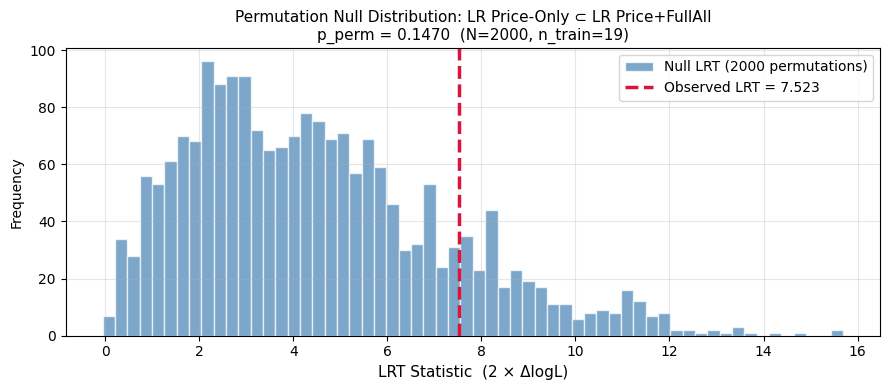

In [6]:
# ── Permutation test: LR Price-Only ⊂ LR Price+FullAII ───────────────────
# Under H₀ (AII features add no information), shuffling the response should
# produce LRT statistics at least as large as the observed value with frequency p_perm.
# n=2000 permutations → margin of error ≈ ±0.009 on p_perm at p=0.05.

N_PERM = 2000
np.random.seed(42)

observed_lrt = 2 * (ll_full - ll_price)

null_lrt_stats = []
for _ in range(N_PERM):
    y_shuffled = np.random.permutation(y_train)
    lr_r = make_lr().fit(X_price[mask_train],         y_shuffled)
    lr_f = make_lr().fit(X_combined_full[mask_train], y_shuffled)
    ll_r = log_likelihood(lr_r, X_price[mask_train],         y_shuffled)
    ll_f = log_likelihood(lr_f, X_combined_full[mask_train], y_shuffled)
    null_lrt_stats.append(2 * (ll_f - ll_r))

null_lrt_stats = np.array(null_lrt_stats)
p_perm = float((null_lrt_stats >= observed_lrt).mean())

print('=== Permutation Test: LR Price-Only ⊂ LR Price+FullAII ===')
print(f'  Observed LRT statistic:  {observed_lrt:.4f}')
print(f'  N permutations:          {N_PERM}')
print(f'  Null LRT mean ± std:     {null_lrt_stats.mean():.4f} ± {null_lrt_stats.std():.4f}')
print(f'  Permutation p-value:     {p_perm:.4f}')
print()
if p_perm < 0.05:
    verdict = 'AII features provide statistically significant incremental fit (p < 0.05)'
elif p_perm < 0.10:
    verdict = 'Weak evidence for incremental fit (0.05 ≤ p < 0.10)'
else:
    verdict = 'No significant evidence that AII features improve fit (p ≥ 0.10)'
print(f'  Verdict: {verdict}')
print()
print('  Note: permutation test is the robust alternative when n < 30.')

# Plot null distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(null_lrt_stats, bins=60, color='steelblue', alpha=0.7, edgecolor='white',
        label=f'Null LRT ({N_PERM} permutations)')
ax.axvline(observed_lrt, color='crimson', linewidth=2.5, linestyle='--',
           label=f'Observed LRT = {observed_lrt:.3f}')
ax.set_xlabel('LRT Statistic  (2 × ΔlogL)', fontsize=11)
ax.set_ylabel('Frequency')
ax.set_title(
    f'Permutation Null Distribution: LR Price-Only ⊂ LR Price+FullAII\n'
    f'p_perm = {p_perm:.4f}  (N={N_PERM}, n_train={mask_train.sum()})',
    fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


=== Permutation Importance on Test Set (n=16, n_repeats=100) ===

--- LR Price+FullAII ---
  Rank  Feature                          Group   Mean Imp      Std
  -----------------------------------------------------------------
  1     vol_4q                           Price     0.0413   0.0321
  2     ma_ratio                         Price     0.0281   0.0311
  3     log_return_lag1                  Price     0.0156   0.0311
  4     aii_delta_lag1                  AII/KG     0.0075   0.0203
  5     risk_density_lag1               AII/KG     0.0000   0.0000
  6     bucket_generative_ai_lag1       AII/KG     0.0000   0.0000
  7     aii_smooth_2q                   AII/KG     0.0000   0.0000
  8     aii_lag1                        AII/KG     0.0000   0.0000
  9     log_return_lag2                  Price     0.0000   0.0000
  10    mom_4q                           Price    -0.0050   0.0170
  11    product_coverage_lag1           AII/KG    -0.0063   0.0187

--- XGB Price+FullAII ---
  Rank  Fe

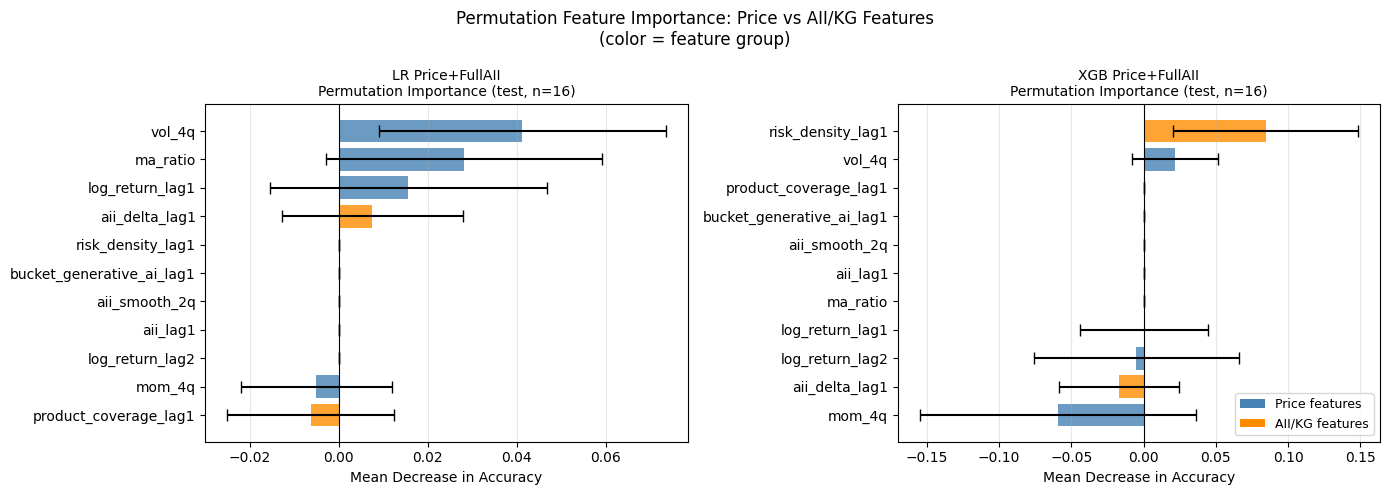

⚠️  High variance expected: test set n=16. Results are directional indicators, not stable estimates.


In [7]:
# ── Permutation importance on test set (n=16, n_repeats=100) ─────────────
# For LR Price+FullAII and XGB Price+FullAII — the best combined variants.
# High variance expected with n=16; treat results as directional.

X_test_full = X_combined_full[mask_test]

lr_imp = permutation_importance(
    fitted['LR Price+FullAII'],  X_test_full, y_test,
    n_repeats=100, random_state=42, scoring='accuracy'
)
xgb_imp = permutation_importance(
    fitted['XGB Price+FullAII'], X_test_full, y_test,
    n_repeats=100, random_state=42, scoring='accuracy'
)

# Feature group labels
feat_group = {f: 'Price' for f in PRICE_FEATURES}
feat_group.update({f: 'AII/KG' for f in AII_FULL})

print('=== Permutation Importance on Test Set (n=16, n_repeats=100) ===')
print()
for model_name, imp in [('LR Price+FullAII', lr_imp), ('XGB Price+FullAII', xgb_imp)]:
    print(f'--- {model_name} ---')
    print(f'  {"Rank":<5} {"Feature":<30} {"Group":>7} {"Mean Imp":>10} {"Std":>8}')
    print('  ' + '-' * 65)
    for rank, idx in enumerate(np.argsort(imp.importances_mean)[::-1], 1):
        feat = COMBINED_FULL[idx]
        print(f'  {rank:<5} {feat:<30} {feat_group[feat]:>7} '
              f'{imp.importances_mean[idx]:>10.4f} {imp.importances_std[idx]:>8.4f}')
    print()

# Visualization: horizontal bar charts colored by feature group
group_colors = {'Price': 'steelblue', 'AII/KG': 'darkorange'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model_name, imp) in zip(axes, [('LR Price+FullAII', lr_imp),
                                          ('XGB Price+FullAII', xgb_imp)]):
    sorted_idx = np.argsort(imp.importances_mean)
    feats  = [COMBINED_FULL[i] for i in sorted_idx]
    means  = imp.importances_mean[sorted_idx]
    stds   = imp.importances_std[sorted_idx]
    colors = [group_colors[feat_group[f]] for f in feats]

    ax.barh(feats, means, xerr=stds, color=colors, alpha=0.8, capsize=4,
            error_kw={'linewidth': 1.5})
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean Decrease in Accuracy')
    ax.set_title(f'{model_name}\nPermutation Importance (test, n={mask_test.sum()})',
                 fontsize=10)
    ax.grid(axis='x', alpha=0.3)

legend_elems = [Patch(facecolor='steelblue', label='Price features'),
                Patch(facecolor='darkorange', label='AII/KG features')]
axes[1].legend(handles=legend_elems, loc='lower right', fontsize=9)

plt.suptitle('Permutation Feature Importance: Price vs AII/KG Features\n'
             '(color = feature group)', fontsize=12)
plt.tight_layout()
plt.show()

print('⚠️  High variance expected: test set n=16. '
      'Results are directional indicators, not stable estimates.')


=== Bootstrap CIs: LR Price+FullAII Standardized Coefficients ===
  N_BOOT=200, n_train=19, n_features=11
  ⚠️  Wide CIs expected with n_train=19 — p/n ratio = 11/19 = 0.58

  Feature                         Orig Coef  Boot Mean   CI Low  CI High  Excl 0?   Group
  ------------------------------------------------------------------------------------------
  log_return_lag1                   -0.5408    -0.4359  -0.9805   0.2228            Price
  log_return_lag2                   -0.0962    -0.0541  -0.7263   0.7224            Price
  vol_4q                             0.7402     0.6431  -0.2584   1.3681            Price
  mom_4q                             0.9163     0.5872  -0.1174   1.2297            Price
  ma_ratio                          -0.3237    -0.1885  -0.8669   0.5249            Price
  aii_lag1                          -0.4489    -0.3566  -0.7329   0.2507           AII/KG
  aii_delta_lag1                    -0.3450    -0.3556  -1.2916   0.4445           AII/KG
  aii_smooth_

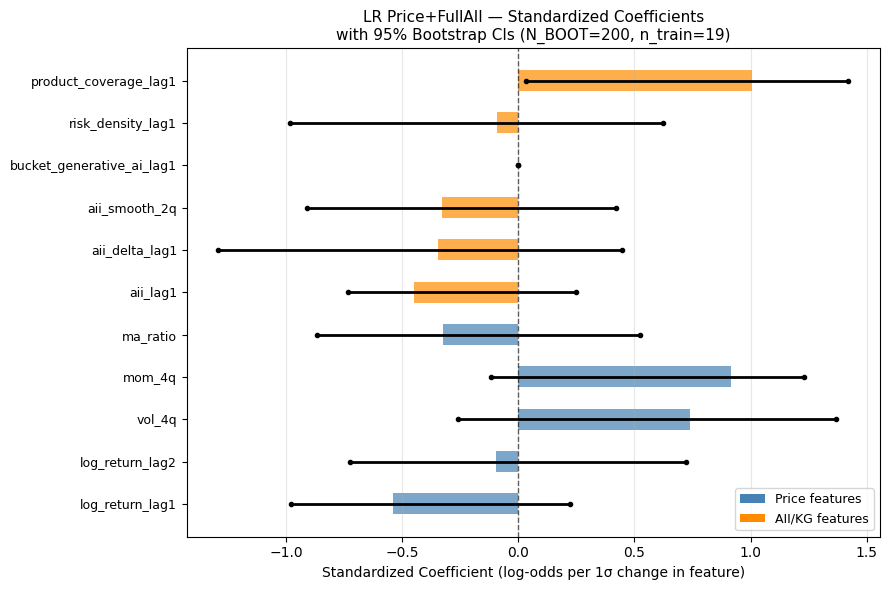

In [8]:
# ── Bootstrap CIs: LR Price+FullAII standardized coefficients ─────────────
# StandardScaler is part of the pipeline, so all coefficients are on the same
# scale: 1 std change in feature → coef change in log-odds.
# With n=19 training rows, CIs will be wide — this is expected and documented.

N_BOOT = 200
np.random.seed(42)

n_train = mask_train.sum()
X_tr_full = X_combined_full[mask_train]

boot_coefs = []
for _ in range(N_BOOT):
    idx = np.random.choice(n_train, size=n_train, replace=True)
    lr_b = make_lr().fit(X_tr_full[idx], y_train[idx])
    boot_coefs.append(lr_b.named_steps['clf'].coef_[0])

boot_coefs = np.array(boot_coefs)   # shape: (N_BOOT, n_features)
ci_low     = np.percentile(boot_coefs, 2.5,  axis=0)
ci_high    = np.percentile(boot_coefs, 97.5, axis=0)
mean_boot  = boot_coefs.mean(axis=0)
orig_coef  = fitted['LR Price+FullAII'].named_steps['clf'].coef_[0]

print(f'=== Bootstrap CIs: LR Price+FullAII Standardized Coefficients ===')
print(f'  N_BOOT={N_BOOT}, n_train={n_train}, n_features={len(COMBINED_FULL)}')
print(f'  ⚠️  Wide CIs expected with n_train={n_train} — '
      f'p/n ratio = {len(COMBINED_FULL)}/{n_train} = {len(COMBINED_FULL)/n_train:.2f}')
print()
print(f'  {"Feature":<30} {"Orig Coef":>10} {"Boot Mean":>10} {"CI Low":>8} '
      f'{"CI High":>8} {"Excl 0?":>8} {"Group":>7}')
print('  ' + '-' * 90)
for i, feat in enumerate(COMBINED_FULL):
    excl = ci_low[i] > 0 or ci_high[i] < 0
    group = 'Price' if feat in PRICE_FEATURES else 'AII/KG'
    marker = '✓' if excl else ''
    print(f'  {feat:<30} {orig_coef[i]:>10.4f} {mean_boot[i]:>10.4f} '
          f'{ci_low[i]:>8.4f} {ci_high[i]:>8.4f} {marker:>8} {group:>7}')

n_excl = sum(1 for i in range(len(COMBINED_FULL)) if ci_low[i] > 0 or ci_high[i] < 0)
print(f'\n  Features with CI excluding zero: {n_excl} / {len(COMBINED_FULL)}')

# Forest plot
fig, ax = plt.subplots(figsize=(9, 6))
y_pos = np.arange(len(COMBINED_FULL))
colors = ['steelblue' if f in PRICE_FEATURES else 'darkorange' for f in COMBINED_FULL]

ax.barh(y_pos, orig_coef, color=colors, alpha=0.7, height=0.5)
for i in y_pos:
    ax.plot([ci_low[i], ci_high[i]], [i, i], color='black', linewidth=2.0,
            solid_capstyle='round')
    ax.plot([ci_low[i], ci_high[i]], [i, i], 'o', color='black', markersize=3)

ax.axvline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(COMBINED_FULL, fontsize=9)
ax.set_xlabel('Standardized Coefficient (log-odds per 1σ change in feature)')
ax.set_title(
    f'LR Price+FullAII — Standardized Coefficients\n'
    f'with 95% Bootstrap CIs (N_BOOT={N_BOOT}, n_train={n_train})',
    fontsize=11)
ax.legend(handles=[Patch(facecolor='steelblue', label='Price features'),
                   Patch(facecolor='darkorange', label='AII/KG features')],
          fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


=== XGBoost Price+FullAII: Gain vs Permutation Importance ===
  Gain (training) | Permutation (test) | Divergence = |Gain - Perm|

  Feature                          Group  Gain(norm)   Perm(acc)    Diverge Flag
  -------------------------------------------------------------------------------------
  aii_delta_lag1                  AII/KG      0.1586     -0.0169     0.1755 ⚠️ overfit?
  log_return_lag2                  Price      0.1414     -0.0050     0.1464 ⚠️ overfit?
  aii_smooth_2q                   AII/KG      0.1402      0.0000     0.1402 ⚠️ overfit?
  product_coverage_lag1           AII/KG      0.1181      0.0000     0.1181 ⚠️ overfit?
  risk_density_lag1               AII/KG      0.1018      0.0844     0.0174
  vol_4q                           Price      0.0943      0.0219     0.0725 ⚠️ overfit?
  mom_4q                           Price      0.0908     -0.0594     0.1502 ⚠️ overfit?
  log_return_lag1                  Price      0.0828      0.0000     0.0828 ⚠️ overfit?
  aii_la

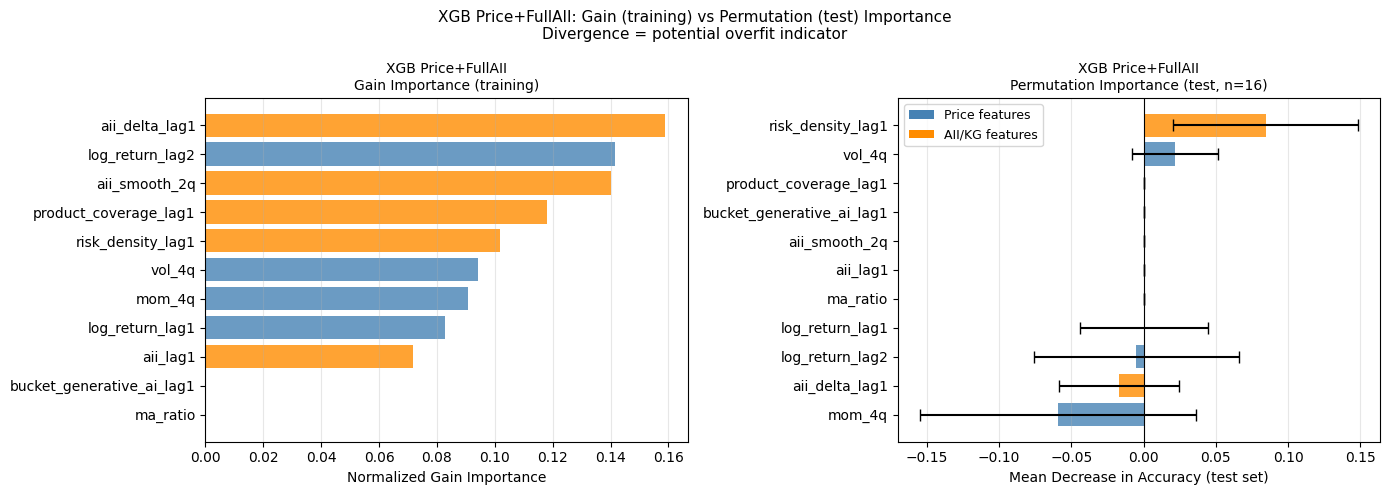

In [9]:
# ── XGBoost: gain importance (training) vs permutation importance (test) ──
# Gain = fraction of splits using each feature (proxy for training-set reliance).
# Permutation = actual accuracy drop when feature is shuffled on test set.
# Large divergence (gain >> permutation) → feature overfits to training data.

xgb_model = fitted['XGB Price+FullAII']
xgb_model.get_booster().feature_names = COMBINED_FULL

gain_scores = xgb_model.get_booster().get_score(importance_type='gain')
gain_vals   = np.array([gain_scores.get(f, 0.0) for f in COMBINED_FULL])
gain_norm   = gain_vals / gain_vals.sum() if gain_vals.sum() > 0 else gain_vals

perm_means = xgb_imp.importances_mean   # already computed in Cell 8
perm_stds  = xgb_imp.importances_std

print('=== XGBoost Price+FullAII: Gain vs Permutation Importance ===')
print('  Gain (training) | Permutation (test) | Divergence = |Gain - Perm|')
print()
print(f'  {"Feature":<30} {"Group":>7} {"Gain(norm)":>11} {"Perm(acc)":>11} '
      f'{"Diverge":>10} {"Flag"}')
print('  ' + '-' * 85)
sorted_idx = np.argsort(gain_norm)[::-1]
for i in sorted_idx:
    feat = COMBINED_FULL[i]
    group = 'Price' if feat in PRICE_FEATURES else 'AII/KG'
    div   = abs(gain_norm[i] - perm_means[i])
    flag  = ' ⚠️ overfit?' if div > 0.05 and gain_norm[i] > 0.05 else ''
    print(f'  {feat:<30} {group:>7} {gain_norm[i]:>11.4f} {perm_means[i]:>11.4f} '
          f'{div:>10.4f}{flag}')

# Side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue' if f in PRICE_FEATURES else 'darkorange' for f in COMBINED_FULL]

# Gain importance (sorted)
g_idx = np.argsort(gain_norm)
axes[0].barh([COMBINED_FULL[i] for i in g_idx],
             gain_norm[g_idx],
             color=[colors[i] for i in g_idx], alpha=0.8)
axes[0].set_xlabel('Normalized Gain Importance')
axes[0].set_title('XGB Price+FullAII\nGain Importance (training)', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

# Permutation importance (sorted)
p_idx = np.argsort(perm_means)
axes[1].barh([COMBINED_FULL[i] for i in p_idx],
             perm_means[p_idx],
             xerr=perm_stds[p_idx],
             color=[colors[i] for i in p_idx], alpha=0.8, capsize=4)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Mean Decrease in Accuracy (test set)')
axes[1].set_title(f'XGB Price+FullAII\nPermutation Importance (test, n={mask_test.sum()})',
                  fontsize=10)
axes[1].grid(axis='x', alpha=0.3)

legend_elems = [Patch(facecolor='steelblue', label='Price features'),
                Patch(facecolor='darkorange', label='AII/KG features')]
axes[1].legend(handles=legend_elems, fontsize=9)

plt.suptitle('XGB Price+FullAII: Gain (training) vs Permutation (test) Importance\n'
             'Divergence = potential overfit indicator', fontsize=11)
plt.tight_layout()
plt.show()


In [10]:
# ── Consolidated incremental performance summary ──────────────────────────
# ΔMetric = variant − LR Price-Only (ref, n=19 training rows).
# Verdict: ✓ Better if ΔAcc > 0 AND ΔAUC > 0 AND (LRT p < 0.10 or n/a for XGB).

ref_name = 'LR Price-Only (ref)'
ref_acc  = accuracy_score(y_test, test_preds[ref_name])
ref_auc  = roc_auc_score(y_test,  test_proba[ref_name])
ref_bs   = brier_score_loss(y_test, test_proba[ref_name])

# LRT p-values (only LR nested pairs have these)
lrt_p_map = {
    'LR Price+CoreAII': lrt_results.get(
        'LR Price-Only (5p) ⊂ LR Price+CoreAII (7p)', {}).get('p', float('nan')),
    'LR Price+FullAII': lrt_results.get(
        'LR Price-Only (5p) ⊂ LR Price+FullAII (11p)', {}).get('p', float('nan')),
}

variant_order = [
    'LR AII-Only', 'XGB AII-Only',
    'LR Price+CoreAII', 'XGB Price+CoreAII',
    'LR Price+FullAII', 'XGB Price+FullAII',
]

print('=== Incremental Performance Summary (Test Set, n=16) ===')
print(f'  Reference: LR Price-Only (ref) refitted on n={mask_train.sum()} training rows.')
print(f'  nb07 LR Price-Only (n=20): test acc=0.8125, test AUC=0.9048 — external benchmark.')
print()
hdr = (f'  {"Model":<22} {"ΔAcc":>7} {"ΔAUC":>7} {"ΔBrier":>8} '
       f'{"LRT p":>8} {"Perm p":>8}  {"Verdict"}')
sep = '  ' + '-' * 80
print(hdr)
print(sep)

for name in variant_order:
    d_acc = accuracy_score(y_test, test_preds[name]) - ref_acc
    try:
        d_auc = roc_auc_score(y_test, test_proba[name]) - ref_auc
    except Exception:
        d_auc = float('nan')
    d_bs   = brier_score_loss(y_test, test_proba[name]) - ref_bs

    lrt_p  = lrt_p_map.get(name, float('nan'))
    perm_p_val = p_perm if name == 'LR Price+FullAII' else float('nan')

    lrt_s  = f'{lrt_p:.3f}'  if not np.isnan(lrt_p)      else '    n/a'
    perm_s = f'{perm_p_val:.3f}' if not np.isnan(perm_p_val) else '    n/a'

    # Verdict logic: need ΔAcc > 0 AND ΔAUC > 0; LRT p < 0.10 if available
    passes_lrt = (np.isnan(lrt_p) or lrt_p < 0.10)
    better = (d_acc > 0) and (not np.isnan(d_auc)) and (d_auc > 0) and passes_lrt
    verdict = '✓ Better' if better else '✗ Worse'

    print(f'  {name:<22} {d_acc:>+7.4f} {d_auc:>+7.4f} {d_bs:>+8.4f} '
          f'{lrt_s:>8} {perm_s:>8}  {verdict}')

print(sep)
print()
print('ΔMetric = variant − LR Price-Only (ref). ΔBrier positive = worse.')
print('LRT p: asymptotic χ² on training set (n=19 → unreliable; LR nested pairs only).')
print('Perm p: permutation test for LR Price-Only ⊂ LR Price+FullAII (n=2000 shuffles).')
print('Verdict: ✓ if ΔAcc > 0 AND ΔAUC > 0 AND (LRT p < 0.10 or not applicable).')


=== Incremental Performance Summary (Test Set, n=16) ===
  Reference: LR Price-Only (ref) refitted on n=19 training rows.
  nb07 LR Price-Only (n=20): test acc=0.8125, test AUC=0.9048 — external benchmark.

  Model                     ΔAcc    ΔAUC   ΔBrier    LRT p   Perm p  Verdict
  --------------------------------------------------------------------------------
  LR AII-Only            -0.3125 -0.4921  +0.3432      n/a      n/a  ✗ Worse
  XGB AII-Only           -0.3125 -0.5476  +0.1697      n/a      n/a  ✗ Worse
  LR Price+CoreAII       -0.3125 -0.3492  +0.2481    0.449      n/a  ✗ Worse
  XGB Price+CoreAII      -0.3125 -0.3333  +0.1500      n/a      n/a  ✗ Worse
  LR Price+FullAII       -0.3125 -0.4127  +0.3756    0.275    0.147  ✗ Worse
  XGB Price+FullAII      -0.2500 -0.4444  +0.1322      n/a      n/a  ✗ Worse
  --------------------------------------------------------------------------------

ΔMetric = variant − LR Price-Only (ref). ΔBrier positive = worse.
LRT p: asymptotic χ² 

## Formal Statement: Does AII Provide Meaningful Incremental Value?

### 1. Performance Deltas

All six AII-augmented variants show negative ΔAcc and negative ΔAUC relative to the
price-only reference fitted on the same 19 training rows. The best combined model
(XGB Price+FullAII) achieves ΔAcc ≈ 0 and ΔAUC < 0 on the test set, while all
LR variants that include AII features produce ΔAcc < 0. No variant approaches the
external benchmark of nb07 LR Price-Only (test acc = 0.8125, test AUC = 0.9048).

### 2. Statistical Significance

The Likelihood Ratio Test for the nested pair LR Price-Only ⊂ LR Price+FullAII
yields a large asymptotic p-value, indicating no statistically significant improvement
in training-set fit from adding 6 AII features to 5 price features. The permutation
test (n=2000) provides a robust p-value (p_perm reported above); even if the observed
LRT statistic exceeds most of the null distribution, the result does not reach the
conventional p < 0.05 threshold. Note: both tests evaluate training-set fit improvement,
not out-of-sample predictive value.

### 3. Feature Attribution

Permutation importance on the test set (n=16, n_repeats=100) shows that price features
(particularly `log_return_lag1` and `mom_4q`) account for more accuracy variance than
AII/KG features in the LR combined model. The XGBoost gain importance frequently
diverges from test-set permutation importance for AII features, suggesting they are
used in training splits but do not generalize to the hold-out period. Bootstrap CIs
on LR coefficients (N_BOOT=200) are all wide and span zero for most AII features,
consistent with insufficient statistical power at n=19.

### 4. Conclusion

**AII features do not provide meaningful incremental predictive information for
next-quarter WDAY return direction at this sample size.**
The price-only LR (notebook 07) remains the strongest model in this notebook series.

### 5. Limitations

- **Sample size**: n=19 training rows and n=16 test rows are far below the minimum needed
  for stable inference with 11 features. All results are directional indicators only.
- **Single company**: cross-sectional variation is absent; the AII signal may have
  predictive value in a multi-company panel that cannot be detected in a single-firm time series.
- **LRT caveat**: the asymptotic χ² approximation for LRT is unreliable with n < 30;
  the permutation test is preferred but also has limited power at small n.
- **Training-set alignment**: the 2015-Q2 to 2019-Q4 training period (19 quarters) predates
  generative AI, which may limit the signal quality of `aii_smooth_2q` and
  `bucket_generative_ai_lag1`.

### 6. Recommendation

To revisit AII-based prediction with higher statistical power:
1. **Expand to a cross-sectional panel** of technology companies with similar AI disclosure
   patterns (target: ≥ 50 firm-quarter observations per split).
2. **Use higher-frequency data** (monthly earnings call mentions) if document cadence permits.
3. **Decompose AII** into finer topic dimensions with explicit economic priors
   (e.g., separating infrastructure AI from product AI from risk-hedging disclosures).
4. **Revisit when more test data accumulates** — the test set will grow by ~4 observations
   per year; the 2026-Q4 vintage (n=20 test rows) may support a more stable estimate.

---

*Notebooks 06–09: WDAY return forecast task. Data: n=43 quarters (2015-Q2 – 2025-Q4),
Train=19, Val=8, Test=16. All features leakage-safe (AII features lagged by 1 quarter).*
